# 🧠 Section 01. CNN 개요 및 핵심 구성 요소
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- NumPy로 2D 합성곱(Conv2d) 연산을 직접 구현하고, PyTorch 결과와 비교 검증한다
- 필터 크기·패딩·스트라이드 변경에 따른 출력 크기 변화를 실험으로 확인한다
- 다양한 필터(엣지 검출, 블러 등)를 적용해 특징 맵(Feature Map)을 시각화한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | 합성(Synthetic) 데이터 |
| 크기 | NumPy로 직접 생성 |
| 클래스 | 해당 없음 |
| 출처 | NumPy 직접 생성 + matplotlib 샘플 이미지 |

> 이번 섹션은 외부 데이터셋 없이, 숫자 배열을 직접 만들어 Conv 연산의 원리를 확인합니다.

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

**환경이 아직 설정되지 않았다면:**
```bash
conda env create -f environment.yml
conda activate cnn-course
```

**Jupyter Lab 실행:**
```bash
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다. CPU만 있어도 실습에 지장 없습니다.

In [3]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# 디바이스 자동 감지
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ torchvision 버전: {torchvision.__version__}")

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

✅ 사용 디바이스: cpu
✅ PyTorch 버전: 2.2.2
✅ torchvision 버전: 0.17.2


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 사용 가능한 한글 폰트 후보
font_candidates = [
    "AppleGothic",
    "NanumGothic",
    "NanumMyeongjo",
    "Malgun Gothic",
    "Noto Sans CJK KR",
    "Noto Sans KR"
]

# 2. 실제 존재하는 폰트 파일만 필터링
available_fonts = []

for font in fm.fontManager.ttflist:
    if os.path.exists(font.fname):
        available_fonts.append(font)

# 3. 후보 폰트 중 실제 사용 가능한 폰트 찾기
selected_font = None

for candidate in font_candidates:
    for font in available_fonts:
        if candidate.lower() in font.name.lower():
            selected_font = font.name
            break
    if selected_font:
        break

# 4. 폰트 적용
if selected_font:
    plt.rcParams["font.family"] = selected_font
    plt.rcParams["axes.unicode_minus"] = False
    print(f"적용 폰트: {selected_font}")
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다.")
    print("맥이라면 보통 AppleGothic을 사용할 수 있습니다.")

적용 폰트: AppleGothic


In [6]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

FileNotFoundError: [Errno 2] No such file or directory: '/System/Library/AssetsV2/com_apple_MobileAsset_Font7/70816a43827731d40efe234b94feba96db91024f.asset/AssetData/NanumMyeongjo.ttc'

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 📁 합성 데이터 소개

이번 실습에서는 외부 데이터셋 없이 두 종류의 입력을 사용합니다.

| 종류 | 설명 | 목적 |
|------|------|------|
| NumPy 배열 | 직접 설계한 간단한 숫자 행렬 | Conv 연산 원리 검증 |
| 실제 이미지 | `matplotlib` 내장 샘플 이미지 | 필터 효과 시각화 |

처음에는 숫자가 작은 배열로 연산 결과를 눈으로 직접 확인하고,  
이후 실제 이미지에 다양한 필터를 적용해 특징 맵을 시각화합니다.

---
## 실습 1. 이미지 데이터 구조 이해

이미지가 컴퓨터에 어떻게 저장되는지 직접 확인해봅니다.

컬러 이미지 shape: (600, 512, 3)  → (H, W, C)
픽셀값 범위: 0 ~ 255
흑백 이미지 shape: (600, 512)  → (H, W)


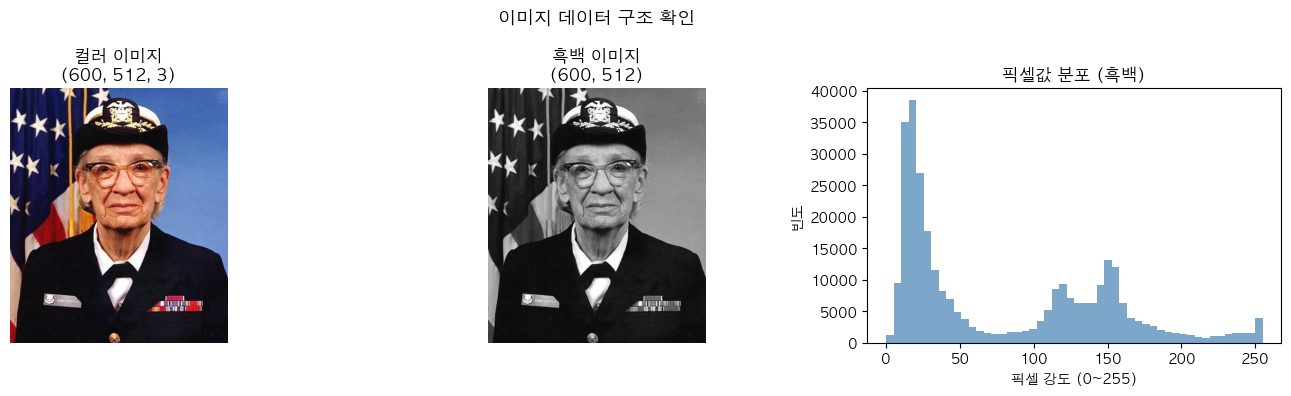

In [8]:
# ─────────────────────────────────────────────
# 1-1. 흑백 이미지: (H, W) 구조 확인
# ─────────────────────────────────────────────

# matplotlib 내장 이미지 로드
img_color = plt.imread(plt.matplotlib.cbook.get_sample_data('grace_hopper.jpg'))
print(f"컬러 이미지 shape: {img_color.shape}  → (H, W, C)")
print(f"픽셀값 범위: {img_color.min()} ~ {img_color.max()}")

# 흑백 변환 (가중 평균)
img_gray = np.mean(img_color, axis=2)
print(f"흑백 이미지 shape: {img_gray.shape}  → (H, W)")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_color)
axes[0].set_title(f"컬러 이미지\n{img_color.shape}")
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title(f"흑백 이미지\n{img_gray.shape}")
axes[1].axis('off')

# 픽셀값 히스토그램
axes[2].hist(img_gray.ravel(), bins=50, color='steelblue', alpha=0.7)
axes[2].set_title("픽셀값 분포 (흑백)")
axes[2].set_xlabel("픽셀 강도 (0~255)")
axes[2].set_ylabel("빈도")

plt.suptitle("이미지 데이터 구조 확인", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ─────────────────────────────────────────────
# 1-2. PyTorch 텐서 형식: (N, C, H, W)
# ─────────────────────────────────────────────

# NumPy (H, W, C) → PyTorch (N, C, H, W) 변환
img_tensor = torch.from_numpy(img_color).float()         # (H, W, C)
img_tensor = img_tensor.permute(2, 0, 1)                 # (C, H, W)
img_tensor = img_tensor.unsqueeze(0)                     # (N, C, H, W)

print("=== 텐서 형태 변환 과정 ===")
print(f"원본 NumPy:        {img_color.shape}  (H, W, C)")
print(f"permute 후:        {img_tensor.squeeze(0).shape}  (C, H, W)")
print(f"unsqueeze 후:      {img_tensor.shape}  (N, C, H, W)")

# 정규화 (0~255 → 0~1)
img_normalized = img_tensor / 255.0
print(f"\n정규화 전 범위: {img_tensor.min():.1f} ~ {img_tensor.max():.1f}")
print(f"정규화 후 범위: {img_normalized.min():.3f} ~ {img_normalized.max():.3f}")

=== 텐서 형태 변환 과정 ===
원본 NumPy:        (600, 512, 3)  (H, W, C)
permute 후:        torch.Size([3, 600, 512])  (C, H, W)
unsqueeze 후:      torch.Size([1, 3, 600, 512])  (N, C, H, W)

정규화 전 범위: 0.0 ~ 255.0
정규화 후 범위: 0.000 ~ 1.000


/var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/ipykernel_27943/2312552454.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  img_tensor = torch.from_numpy(img_color).float()         # (H, W, C)


---
## 실습 2. NumPy로 2D Conv 연산 직접 구현

합성곱 연산을 NumPy 슬라이딩 윈도우로 직접 구현한 뒤,  
PyTorch의 `nn.Conv2d` 결과와 비교해 원리를 검증합니다.

> 💡 **직관**: 필터를 이미지 위에서 슬라이딩하며, 겹치는 영역의 원소별 곱셈 합(내적)을 계산합니다.

In [10]:
# ─────────────────────────────────────────────
# 2-1. 검증용 작은 입력과 필터 준비
# ─────────────────────────────────────────────

# 5×5 입력 (손으로 추적 가능한 크기)
input_2d = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 0],
    [1, 0, 1, 2, 3],
    [2, 3, 0, 1, 2],
    [3, 2, 1, 0, 1]
], dtype=np.float32)

# 3×3 필터 (수직 엣지 검출기)
kernel_2d = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

print("=== 입력 (5×5) ===")
print(input_2d)
print("\n=== 필터 (3×3 수직 엣지 검출기) ===")
print(kernel_2d)
print(f"\n패딩 없을 때 출력 크기: {(5-3)//1+1} × {(5-3)//1+1}")

=== 입력 (5×5) ===
[[1. 2. 3. 0. 1.]
 [0. 1. 2. 3. 0.]
 [1. 0. 1. 2. 3.]
 [2. 3. 0. 1. 2.]
 [3. 2. 1. 0. 1.]]

=== 필터 (3×3 수직 엣지 검출기) ===
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

패딩 없을 때 출력 크기: 3 × 3


### ✏️ TODO: `conv2d_naive()` 함수 구현

슬라이딩 윈도우 방식으로 2D 합성곱을 직접 구현하세요.  
패딩(padding)과 스트라이드(stride)를 모두 지원해야 합니다.

In [11]:
# ─────────────────────────────────────────────
# TODO: conv2d_naive() 슬라이딩 윈도우 구현
# ─────────────────────────────────────────────

def conv2d_naive(input_arr, kernel, padding=0, stride=1):
    """
    NumPy로 구현한 2D 합성곱 연산 (단일 채널, 단일 필터).

    Args:
        input_arr (np.ndarray): 입력 배열, shape (H, W)
        kernel    (np.ndarray): 합성곱 필터, shape (kH, kW)
        padding   (int): 입력 주변에 추가할 0의 두께 (기본값: 0)
        stride    (int): 필터 이동 간격 (기본값: 1)

    Returns:
        np.ndarray: 특징 맵(feature map), shape (out_H, out_W)
    """
    H, W = input_arr.shape
    kH, kW = kernel.shape

    # ① 패딩 적용: np.pad 사용, 상하좌우 동일하게
    if padding > 0:
        input_padded = np.pad(___, pad_width=___, mode='constant', constant_values=0)
        # 힌트: input_arr을 패딩, pad_width는 ((padding, padding), (padding, padding))
    else:
        input_padded = input_arr.copy()

    # ② 출력 크기 계산
    H_pad, W_pad = input_padded.shape
    out_H = (H_pad - kH) // stride + 1
    out_W = (W_pad - kW) // stride + 1
    output = np.zeros((out_H, out_W), dtype=np.float32)

    # ③ 슬라이딩 윈도우: i, j는 출력 위치 인덱스
    for i in range(out_H):
        for j in range(out_W):
            # 입력에서 필터 크기만큼 잘라내기
            h_start = i * stride
            w_start = j * stride
            patch = input_padded[h_start:h_start+kH, w_start:w_start+kW]

            # 원소별 곱의 합 계산
            output[i, j] = np.sum(___ * kernel)
            # 힌트: patch와 kernel의 원소별 곱(element-wise product)

    return output

print("conv2d_naive() 함수를 구현한 뒤 다음 셀을 실행하세요!")

conv2d_naive() 함수를 구현한 뒤 다음 셀을 실행하세요!


In [12]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------

def conv2d_naive(input_arr, kernel, padding=0, stride=1):
    """
    NumPy로 구현한 2D 합성곱 연산 (단일 채널, 단일 필터).

    Args:
        input_arr (np.ndarray): 입력 배열, shape (H, W)
        kernel    (np.ndarray): 합성곱 필터, shape (kH, kW)
        padding   (int): 입력 주변에 추가할 0의 두께 (기본값: 0)
        stride    (int): 필터 이동 간격 (기본값: 1)

    Returns:
        np.ndarray: 특징 맵(feature map), shape (out_H, out_W)
    """
    H, W = input_arr.shape
    kH, kW = kernel.shape

    if padding > 0:
        input_padded = np.pad(input_arr,
                              pad_width=((padding, padding), (padding, padding)),
                              mode='constant', constant_values=0)
    else:
        input_padded = input_arr.copy()

    H_pad, W_pad = input_padded.shape
    out_H = (H_pad - kH) // stride + 1
    out_W = (W_pad - kW) // stride + 1
    output = np.zeros((out_H, out_W), dtype=np.float32)

    for i in range(out_H):
        for j in range(out_W):
            h_start = i * stride
            w_start = j * stride
            patch = input_padded[h_start:h_start+kH, w_start:w_start+kW]
            output[i, j] = np.sum(patch * kernel)

    return output

print("✅ 정답 함수가 로드되었습니다!")

✅ 정답 함수가 로드되었습니다!


In [13]:
# ─────────────────────────────────────────────
# 2-2. NumPy 구현 결과 확인 + PyTorch 결과와 비교 검증
# ─────────────────────────────────────────────

# NumPy 구현으로 계산
result_numpy = conv2d_naive(input_2d, kernel_2d, padding=0, stride=1)
print("=== NumPy 구현 결과 (3×3) ===")
print(result_numpy.round(3))

# PyTorch로 동일 연산 수행
inp_torch = torch.from_numpy(input_2d).unsqueeze(0).unsqueeze(0)   # (1,1,5,5)
ker_torch = torch.from_numpy(kernel_2d).unsqueeze(0).unsqueeze(0)  # (1,1,3,3)
result_torch = F.conv2d(inp_torch, ker_torch, padding=0, stride=1)
result_torch_np = result_torch.squeeze().numpy()

print("\n=== PyTorch 결과 (3×3) ===")
print(result_torch_np.round(3))

# 최대 오차 확인
max_diff = np.abs(result_numpy - result_torch_np).max()
print(f"\n✅ NumPy vs PyTorch 최대 오차: {max_diff:.6f}")
if max_diff < 1e-4:
    print("   → 구현이 정확합니다! 🎉")
else:
    print("   → 구현을 다시 확인해보세요.")

=== NumPy 구현 결과 (3×3) ===
[[ 4.  2. -2.]
 [ 0.  2.  2.]
 [-4. -2.  4.]]

=== PyTorch 결과 (3×3) ===
[[ 4.  2. -2.]
 [ 0.  2.  2.]
 [-4. -2.  4.]]

✅ NumPy vs PyTorch 최대 오차: 0.000000
   → 구현이 정확합니다! 🎉


---
## 실습 3. 필터 크기 · 패딩 · 스트라이드 실험

세 가지 하이퍼파라미터가 출력 크기에 어떤 영향을 주는지 확인합니다.

> 출력 크기 공식: `⌊(H - kH + 2P) / S⌋ + 1`

In [14]:
# ─────────────────────────────────────────────
# 3-1. 출력 크기 변화 실험
# ─────────────────────────────────────────────

# 7×7 합성 이미지 준비
test_input = np.random.randn(7, 7).astype(np.float32)

configs = [
    {"kernel": 3, "padding": 0, "stride": 1, "label": "k=3, p=0, s=1"},
    {"kernel": 3, "padding": 1, "stride": 1, "label": "k=3, p=1, s=1 (same)"},
    {"kernel": 3, "padding": 0, "stride": 2, "label": "k=3, p=0, s=2"},
    {"kernel": 5, "padding": 0, "stride": 1, "label": "k=5, p=0, s=1"},
    {"kernel": 5, "padding": 2, "stride": 1, "label": "k=5, p=2, s=1 (same)"},
]

print(f"입력 크기: {test_input.shape}")
print("-" * 45)
print(f"{'설정':<25} {'출력 크기':>10}")
print("-" * 45)

for cfg in configs:
    k, p, s = cfg["kernel"], cfg["padding"], cfg["stride"]
    kernel_exp = np.ones((k, k), dtype=np.float32) / (k * k)
    result = conv2d_naive(test_input, kernel_exp, padding=p, stride=s)
    formula = f"({7} - {k} + 2×{p}) / {s} + 1 = {result.shape[0]:.0f}"
    print(f"{cfg['label']:<25} {str(result.shape):>10}   ({formula})")

입력 크기: (7, 7)
---------------------------------------------
설정                             출력 크기
---------------------------------------------
k=3, p=0, s=1                 (5, 5)   ((7 - 3 + 2×0) / 1 + 1 = 5)
k=3, p=1, s=1 (same)          (7, 7)   ((7 - 3 + 2×1) / 1 + 1 = 7)
k=3, p=0, s=2                 (3, 3)   ((7 - 3 + 2×0) / 2 + 1 = 3)
k=5, p=0, s=1                 (3, 3)   ((7 - 5 + 2×0) / 1 + 1 = 3)
k=5, p=2, s=1 (same)          (7, 7)   ((7 - 5 + 2×2) / 1 + 1 = 7)


In [16]:
# ─────────────────────────────────────────────
# 3-2. ✏️ 빈칸: nn.Conv2d 파라미터 설정
# ─────────────────────────────────────────────

# 입력 (1, 1, 28, 28) → 출력 (1, 16, 28, 28) 이 되도록 설정하세요
# 조건: kernel_size=3, 크기 유지(same padding)

conv_same = nn.Conv2d(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1   # 힌트: 3×3 필터로 크기를 유지하려면 패딩이 몇이어야 할까요?
)

x_test = torch.randn(1, 1, 28, 28)
out = conv_same(x_test)
print(f"입력 shape: {x_test.shape}")
print(f"출력 shape: {out.shape}")
assert out.shape == (1, 16, 28, 28), f"❌ 출력 크기가 (1,16,28,28)이어야 합니다. 현재: {out.shape}"
print("✅ 정답입니다!")

입력 shape: torch.Size([1, 1, 28, 28])
출력 shape: torch.Size([1, 16, 28, 28])
✅ 정답입니다!


In [16]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# padding = 1
# 근거: (28 - 3 + 2×1) / 1 + 1 = 28 ← 크기 유지

conv_same = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
x_test = torch.randn(1, 1, 28, 28)
out = conv_same(x_test)
print(f"출력 shape: {out.shape}")  # (1, 16, 28, 28)

출력 shape: torch.Size([1, 16, 28, 28])


---
## 실습 4. 다양한 필터 적용 및 특징 맵 시각화

수작업으로 설계한 필터들을 실제 이미지에 적용해봅니다.  
각 필터가 어떤 특징을 감지하는지 시각적으로 확인합니다.

In [17]:
# ─────────────────────────────────────────────
# 4-1. 필터 정의
# ─────────────────────────────────────────────

filters = {
    "원본": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    "수직 엣지": np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32),
    "수평 엣지": np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32),
    "Sobel X": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "가우시안 블러": np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float32) / 16,
    "샤프닝": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}

# 이미지를 흑백 float로 준비
img = plt.imread(plt.matplotlib.cbook.get_sample_data('grace_hopper.jpg'))
img_gray = np.mean(img, axis=2).astype(np.float32)

print("정의된 필터 목록:")
for name, f in filters.items():
    print(f"  [{name}] shape: {f.shape}, 합계: {f.sum():.2f}")

정의된 필터 목록:
  [원본] shape: (3, 3), 합계: 1.00
  [수직 엣지] shape: (3, 3), 합계: 0.00
  [수평 엣지] shape: (3, 3), 합계: 0.00
  [Sobel X] shape: (3, 3), 합계: 0.00
  [가우시안 블러] shape: (3, 3), 합계: 1.00
  [샤프닝] shape: (3, 3), 합계: 1.00


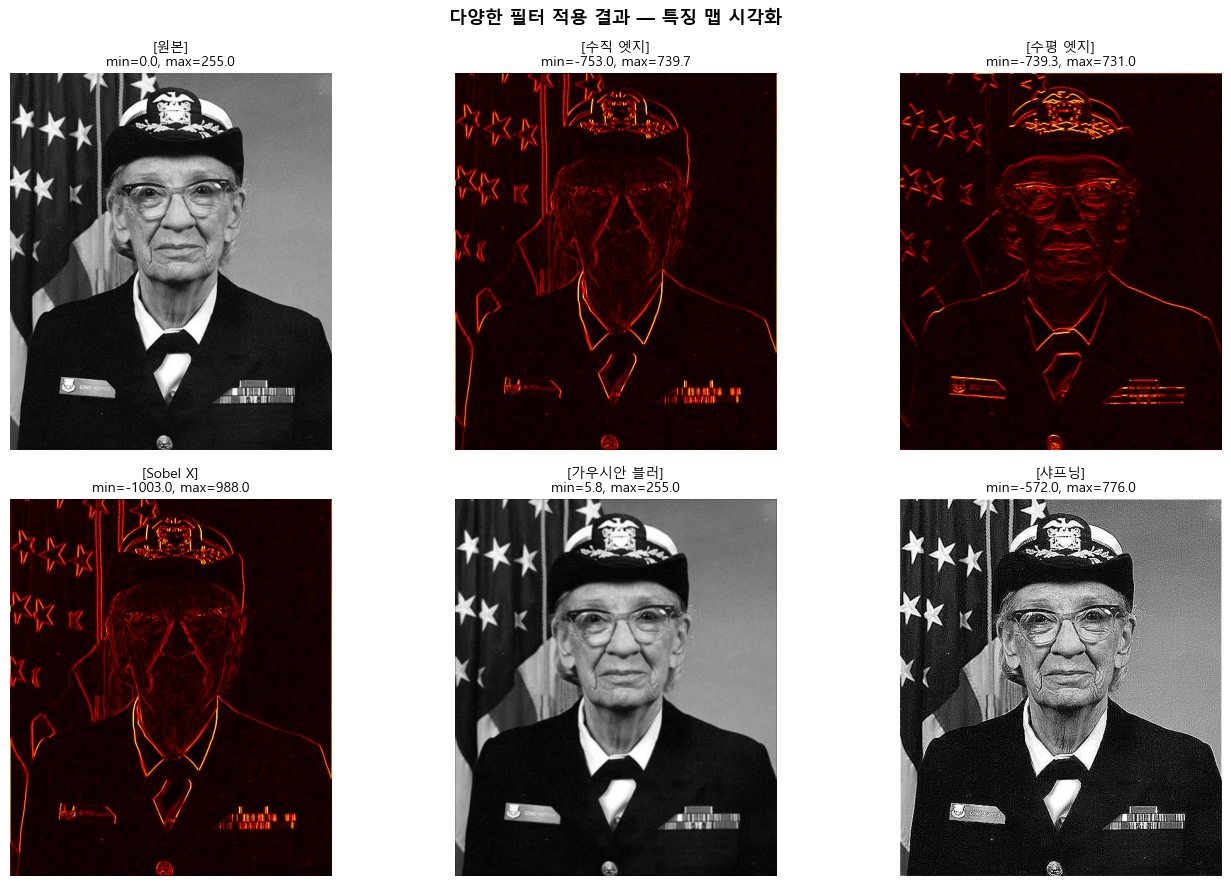


💡 관찰 포인트:
  - 수직/수평 엣지 필터: 해당 방향의 경계선만 강조됩니다
  - 가우시안 블러: 고주파(엣지) 성분이 제거되어 부드러워집니다
  - 샤프닝: 엣지 성분이 강조되어 선명해집니다


In [18]:
# ─────────────────────────────────────────────
# 4-2. 필터 적용 후 특징 맵 시각화
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for idx, (name, kernel) in enumerate(filters.items()):
    feature_map = conv2d_naive(img_gray, kernel, padding=1, stride=1)
    
    # 엣지 필터는 절댓값 표시, 나머지는 0~255 클리핑
    if "엣지" in name or "Sobel" in name:
        display = np.abs(feature_map)
        cmap = 'hot'
    else:
        display = np.clip(feature_map, 0, 255)
        cmap = 'gray'
    
    axes[idx].imshow(display, cmap=cmap)
    axes[idx].set_title(f"[{name}]\nmin={feature_map.min():.1f}, max={feature_map.max():.1f}",
                         fontsize=10)
    axes[idx].axis('off')

plt.suptitle("다양한 필터 적용 결과 — 특징 맵 시각화", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 관찰 포인트:")
print("  - 수직/수평 엣지 필터: 해당 방향의 경계선만 강조됩니다")
print("  - 가우시안 블러: 고주파(엣지) 성분이 제거되어 부드러워집니다")
print("  - 샤프닝: 엣지 성분이 강조되어 선명해집니다")

---
## 실습 5. 실제 CNN의 다채널 합성곱 확인

실제 CNN은 여러 채널 입력에 여러 필터를 동시 적용합니다.  
PyTorch `nn.Conv2d`로 다채널 동작을 확인합니다.

In [ ]:
# ─────────────────────────────────────────────
# 5-1. 다채널 입력 → 다채널 출력
# ─────────────────────────────────────────────

# RGB 이미지 → PyTorch 텐서 변환
img_rgb = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0)  # (1,3,H,W)
print(f"RGB 입력 텐서: {img_rgb.shape}")

# ✏️ 빈칸: 3채널 입력 → 16채널 출력 Conv2d 설정
conv_rgb = nn.Conv2d(
    in_channels=___,  # 힌트: RGB 이미지의 채널 수
    out_channels=16,
    kernel_size=3,
    padding=1
)

with torch.no_grad():
    feature_maps = conv_rgb(img_rgb)

print(f"출력 특징 맵: {feature_maps.shape}")
print(f"  → 16개의 서로 다른 특징 맵이 생성됩니다")

RGB 입력 텐서: torch.Size([1, 3, 600, 512])
출력 특징 맵: torch.Size([1, 16, 600, 512])
  → 16개의 서로 다른 특징 맵이 생성됩니다


In [20]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# in_channels = 3  (R, G, B 세 채널)

conv_rgb = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
with torch.no_grad():
    feature_maps = conv_rgb(img_rgb)
print(f"출력 특징 맵: {feature_maps.shape}")  # (1, 16, H, W)

출력 특징 맵: torch.Size([1, 16, 600, 512])


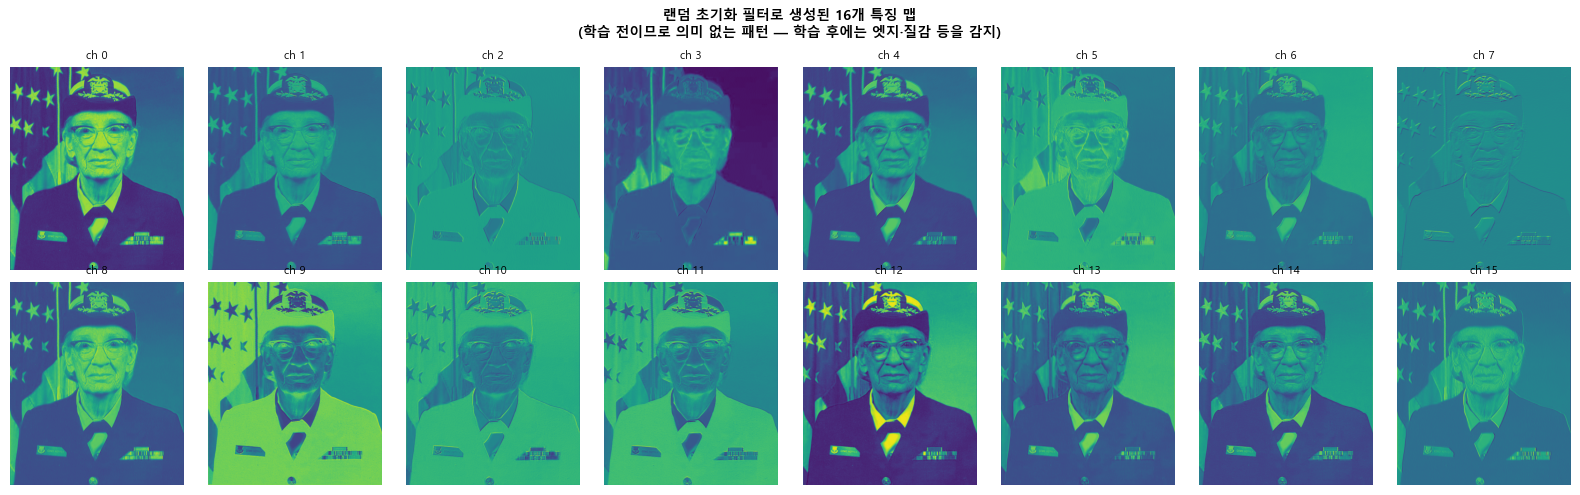

In [21]:
# ─────────────────────────────────────────────
# 5-2. 16개 특징 맵 시각화
# ─────────────────────────────────────────────

fmaps = feature_maps.squeeze().detach().numpy()  # (16, H, W)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(fmaps[idx], cmap='viridis')
    ax.set_title(f"ch {idx}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"랜덤 초기화 필터로 생성된 16개 특징 맵\n"
             f"(학습 전이므로 의미 없는 패턴 — 학습 후에는 엣지·질감 등을 감지)",
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 실습 6. 간단한 CNN 구조 Forward Pass 검증

실습에서 배운 레이어들을 조합해 작은 CNN을 만들고,  
더미 입력으로 각 레이어 통과 시 텐서 크기 변화를 추적합니다.

> ⚠️ **학습 전 forward 검증은 필수 습관입니다!**  
> shape 불일치는 학습 중에도 나지 않다가 FC 레이어에서 `RuntimeError`를 일으킵니다.

In [22]:
# ─────────────────────────────────────────────
# 6-1. 간단한 CNN 정의
# ─────────────────────────────────────────────

class SimpleCNN(nn.Module):
    """
    실습용 간단한 CNN: 입력 (N,1,28,28) → 출력 (N,10)

    구조: Conv→BN→ReLU→Pool → Conv→BN→ReLU→Pool → Flatten → FC
    """

    def __init__(self):
        super().__init__()
        # 특징 추출기
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (N,1,28,28)→(N,16,28,28)
            nn.BatchNorm2d(16),                          # 채널별 정규화
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (N,16,28,28)→(N,16,14,14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # (N,16,14,14)→(N,32,14,14)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (N,32,14,14)→(N,32,7,7)
        )
        # 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # (N,32,7,7)→(N,1568)
            nn.Linear(32 * 7 * 7, 128),                 # (N,1568)→(N,128)
            nn.ReLU(inplace=True),
            nn.Linear(128, 10),                          # (N,128)→(N,10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

총 파라미터 수: 207,018


In [23]:
# ─────────────────────────────────────────────
# 6-2. 레이어별 텐서 크기 추적
# ─────────────────────────────────────────────

dummy = torch.randn(4, 1, 28, 28)  # 배치 4, 흑백, 28×28
print(f"입력:             {dummy.shape}")

# Sequential을 순서대로 통과하며 크기 출력
x = dummy
for i, layer in enumerate(model.features):
    x = layer(x)
    print(f"features[{i}] {type(layer).__name__:<15}: {x.shape}")

print(f"Flatten 후:       {x.view(x.size(0), -1).shape}")
output = model(dummy)
print(f"최종 출력:        {output.shape}")
print("\n✅ Forward pass 성공! shape 불일치 없음")

입력:             torch.Size([4, 1, 28, 28])
features[0] Conv2d         : torch.Size([4, 16, 28, 28])
features[1] BatchNorm2d    : torch.Size([4, 16, 28, 28])
features[2] ReLU           : torch.Size([4, 16, 28, 28])
features[3] MaxPool2d      : torch.Size([4, 16, 14, 14])
features[4] Conv2d         : torch.Size([4, 32, 14, 14])
features[5] BatchNorm2d    : torch.Size([4, 32, 14, 14])
features[6] ReLU           : torch.Size([4, 32, 14, 14])
features[7] MaxPool2d      : torch.Size([4, 32, 7, 7])
Flatten 후:       torch.Size([4, 1568])
최종 출력:        torch.Size([4, 10])

✅ Forward pass 성공! shape 불일치 없음


---
## 🚀 도전 과제

기본 실습을 마쳤다면 아래 과제에 도전해보세요!

### 과제 1. 배치 처리 지원
`conv2d_naive()`를 확장하여 `(N, C, H, W)` 형태의 배치 입력과 다채널 입력/출력을 처리하는  
`conv2d_full(input, weights, bias=None, padding=0, stride=1)` 함수를 구현하세요.

### 과제 2. 학습 가능한 필터 비교
`nn.Conv2d`의 초기화된 가중치를 추출하여 4-2에서 수작업으로 만든 필터와 시각적으로 비교하세요.  
학습되지 않은 랜덤 필터와 수작업 엣지 필터의 차이를 특징 맵으로 비교합니다.

### 과제 3. Depthwise Separable Convolution
일반 `Conv2d(3, 32, 3)`의 파라미터 수와, Depthwise(`groups=3`) + Pointwise(`1×1`) 분리 합성곱의  
파라미터 수를 계산하고 비교하세요. 왜 MobileNet이 이 구조를 사용하는지 이해해봅니다.

```python
# 힌트
conv_standard   = nn.Conv2d(3, 32, 3)           # 파라미터: ?
conv_depthwise  = nn.Conv2d(3, 3, 3, groups=3)  # 파라미터: ?
conv_pointwise  = nn.Conv2d(3, 32, 1)           # 파라미터: ?
```
